In [30]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [31]:
train_dataset = torchvision.datasets.FashionMNIST("/content/drive/MyDrive/CNN", download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("/content/drive/MyDrive/CNN", download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

In [32]:
# torch.utils.data.DataLoader(): 원하는 크기의 배치 단위로 데이터를 불러오거나 순서가 무작위로 섞이도록 할 수 있다.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

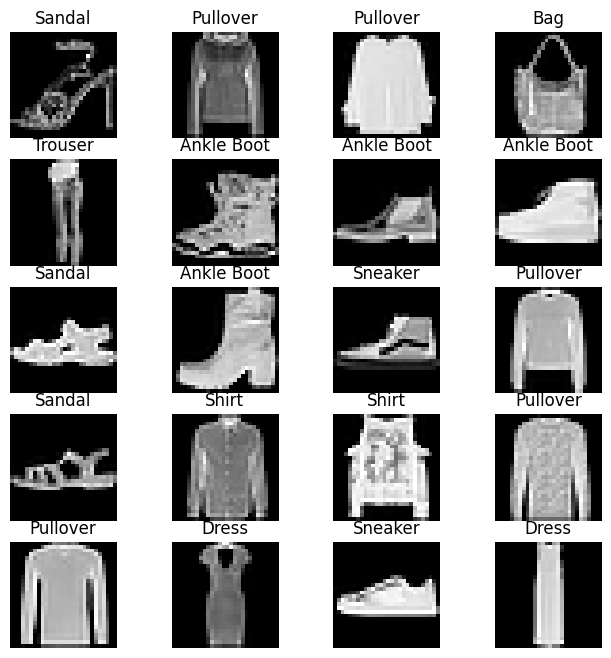

In [33]:
# 클래스 인덱스(0~9)를 사람이 읽을 수 있는 텍스트 라벨로 매핑
labels_map = {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8, 8))  # 그림 크기
columns = 4;  # 가로로 보여줄 이미지 개수
rows = 5;     # 세로로 보여줄 이미지 개수
for i in range(1, columns*rows + 1):

  # np.random.randint: 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용.
  # 따라서 의미는 0~(train_dataset의 길이) 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성해라. (실행할 때마다 매번 다른 옷/신발 확인 가능)
  img_xy = np.random.randint(len(train_dataset));

  # [0,:,:]: (Channel, Height, Width) 형식에서 첫 번째 채널만 선택(흑백)
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])

  # 이미지 주위의 축(0~28 등)을 숨겨서 깔끔하게 표시
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

In [34]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    # 학습 시 무작위로 25%의 뉴런을 끔(과적합 방지)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    # 데이터 펼치기(Flatten): (Batch, 1, 28, 28) 형태를 (Batch, 784)로 변환
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [35]:
learning_rate = 0.001;
model = FashionDNN();

# 손실 함수: 모델의 예측값과 실제 정답 사이의 오차를 계산
# CrossEntropyLoss: 다중 클래스 분류(10개 중 하나 맞히기)에 주로 사용
criterion = nn.CrossEntropyLoss();
# optimizer: 손실 함수를 바탕으로 모델의 가중치를 어떻게 수정할지 결정
# model.parameters(): 모델 안의 모든 가중치(W, b)를 관리하게 함
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [36]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

# 예측값과 실제 정답을 저장
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader: # 배치(Batch) 단위로 데이터 로드

    # 입력 데이터 형태 변환(배치 크기 100, 채널 1, 가로 28, 세로 28)
    train = images.view(100, 1, 28, 28)
    labels = labels

    # 순전파
    outputs = model(train)  # 모델에 데이터를 넣어 예측값 계산
    loss = criterion(outputs, labels) # 예측값과 실제 정답 사이의 오차 계산

    # 역전파 및 최적화
    optimizer.zero_grad() # 이전 루프에서 계산된 기울기를 0으로 초기화
    loss.backward() # 손실 함수를 미분하여 각 가중치의 기울기 계산
    optimizer.step()  # 계산된 기울기를 바탕으로 가중치 업데이트

    count += 1

    if not (count % 50):
      total = 0
      correct = 0

      for images, labels in test_loader:
        labels_list.append(labels)  # 실제 라벨 저장

        test = images.view(100, 1, 28, 28)
        outputs = model(test)

        # torch.max의 결과 [1]은 가장 높은 점수를 받은 클래스의 인덱스를 의미함
        predictions = torch.max(outputs, 1)[1]
        predictions_list.append(predictions)  # 모델의 예측값 저장

        # (예측 == 실제)가 참인 개수를 모두 더한다
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total

      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.6501616835594177, Accuracy: 83.11000061035156%
Iteration: 1000, Loss: 0.47764822840690613, Accuracy: 84.86000061035156%
Iteration: 1500, Loss: 0.35526999831199646, Accuracy: 84.38999938964844%
Iteration: 2000, Loss: 0.33039435744285583, Accuracy: 85.5199966430664%
Iteration: 2500, Loss: 0.23112285137176514, Accuracy: 85.97000122070312%
Iteration: 3000, Loss: 0.32165199518203735, Accuracy: 86.75%


In [40]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()

    # [layer1] 특징: 28x28x1 -> 14x14x32
    self.layer1 = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),  # 32채널 출력, 3x3 필터 사용, 패딩 1(크기 유지)
                                nn.BatchNorm2d(32),
                                nn.ReLU(),
                                # 맥스 풀링: 이미지를 2x2 영역에서 가장 큰 값만 뽑아 1/2로 축소(28x28 -> 14x14)
                                nn.MaxPool2d(kernel_size=2, stride=2))

    # [layer2] 특징: 14x14x32 -> 6x6x64
    self.layer2 = nn.Sequential(nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),  # 32채널 -> 64채널 확장, 3x3 필터, 패딩 0 (크기가 12x12로 줄어듦)
                                nn.BatchNorm2d(64),
                                nn.ReLU(),
                                # 맥스 풀링: 다시 1/2로 축소 (12x12 -> 6x6)
                                nn.MaxPool2d(2))

    # [Fully Connected Layers] 데이터 분류기
    # 64(채널) * 6(가로) * 6(세로) = 2304개의 특징을 입력으로 받
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    # 특징 추출 레이어 통과
    out = self.layer1(x)
    out = self.layer2(out)

    # 데이터를 1차원으로 펼치기(Flatten)
    # out.size(0): 배치 사이즈를 유지하라는 의미
    # -1: 행의 수는 정확히 알고 있지만, 열의 수는 알지 못할 때 사용
    out = out.view(out.size(0), -1)

    # 분류기 통과
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [41]:
learning_rate = 0.001;
model = FashionCNN();

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [42]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

# 예측값과 실제 정답을 저장
predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader: # 배치(Batch) 단위로 데이터 로드

    # 입력 데이터 형태 변환(배치 크기 100, 채널 1, 가로 28, 세로 28)
    train = images.view(100, 1, 28, 28)
    labels = labels

    # 순전파
    outputs = model(train)  # 모델에 데이터를 넣어 예측값 계산
    loss = criterion(outputs, labels) # 예측값과 실제 정답 사이의 오차 계산

    # 역전파 및 최적화
    optimizer.zero_grad() # 이전 루프에서 계산된 기울기를 0으로 초기화
    loss.backward() # 손실 함수를 미분하여 각 가중치의 기울기 계산
    optimizer.step()  # 계산된 기울기를 바탕으로 가중치 업데이트

    count += 1

    if not (count % 50):
      total = 0
      correct = 0

      for images, labels in test_loader:
        labels_list.append(labels)  # 실제 라벨 저장

        test = images.view(100, 1, 28, 28)
        outputs = model(test)

        # torch.max의 결과 [1]은 가장 높은 점수를 받은 클래스의 인덱스를 의미함
        predictions = torch.max(outputs, 1)[1]
        predictions_list.append(predictions)  # 모델의 예측값 저장

        # (예측 == 실제)가 참인 개수를 모두 더한다
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total

      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.39130324125289917, Accuracy: 87.01000213623047%
Iteration: 1000, Loss: 0.3368894159793854, Accuracy: 88.12000274658203%
Iteration: 1500, Loss: 0.3399573564529419, Accuracy: 87.88999938964844%
Iteration: 2000, Loss: 0.2466905564069748, Accuracy: 89.69000244140625%
Iteration: 2500, Loss: 0.1733722686767578, Accuracy: 89.5999984741211%
Iteration: 3000, Loss: 0.15307573974132538, Accuracy: 90.08000183105469%
